# 02 — Mobility-weighted destination PM₂.₅ exposure in Helsinki

**Purpose.** Extend the residential baseline using CAFEIN weekday OD flows. PM₂.₅ is sampled for each neighbourhood, attached to OD destinations, and aggregated into a trip-weighted destination-exposure indicator for each origin neighbourhood.

This notebook also compares origin PM₂.₅ with mobility-weighted destination PM₂.₅. It stops **before** route generation; route exposure is isolated in Notebook 03.


In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

import cafein.sampledata.helsinki as helsinki

print("Air quality:", helsinki.air_quality)
print("OD weekday:", helsinki.mobility.od_weekday)
print("Presence weekday:", helsinki.mobility.presence_weekday)
print("Neighbourhoods:", helsinki.mobility.neighbourhoods)

Air quality: /users/modjrian/.cache/x86_64/cafein-sampledata/helsinki/helsinki-2026.08.4/e9e1a0a02590aae38aaaef126cbfc39c38e788e7e9f9390f9234c9f3461b6b4e/helsinki_air_quality.tif
OD weekday: /users/modjrian/.cache/x86_64/cafein-sampledata/helsinki/helsinki-2026.08.4/c9f14f987a0203898eee0f6bd8f95644d87f7df8c503eba6fe059989a6d3ddd8/hma_od_weekday.parquet
Presence weekday: /users/modjrian/.cache/x86_64/cafein-sampledata/helsinki/helsinki-2026.08.4/ab61a25d529672b95bc1e0a3ad6807d932fd0d05dcc7f92756bcd049c6b14c7d/hma_presence_weekday.parquet
Neighbourhoods: /users/modjrian/.cache/x86_64/cafein-sampledata/helsinki/helsinki-2026.08.4/2f21e21c101e22c87730a30b6283df436f41eb3728758f9734269f237fc2f016/hma_neighbourhoods.gpkg


## 1. Load mobility and neighbourhood data

In [2]:
od = pd.read_parquet(helsinki.mobility.od_weekday)
presence = pd.read_parquet(helsinki.mobility.presence_weekday)
units = gpd.read_file(helsinki.mobility.neighbourhoods)

print("OD:", od.shape, od.columns.tolist())
print("Presence:", presence.shape, presence.columns.tolist())
print("Units:", units.shape, units.columns.tolist(), units.crs)

display(od.head())
display(presence.head())
display(units.head())

OD: (1580938, 4) ['origin', 'destination', 'hour', 'trips']
Presence: (1587394, 4) ['home_unit', 'visited_unit', 'hour', 'presence']
Units: (298, 4) ['Neighbourhood_unit_ID', 'Neighbourhood_name', 'Municipality_name', 'geometry'] EPSG:3067


,origin,destination,hour,trips
0,491011111,491011112,0,59.896716
1,491011111,491011113,0,39.964573
2,491011111,491011114,0,4.011500
3,491011111,491011115,0,10.129039
4,491011111,491011116,0,17.086485


,home_unit,visited_unit,hour,presence
0,491011111,491011111,0,5005.913787
1,491011111,491011112,0,59.896716
2,491011111,491011113,0,39.964573
3,491011111,491011114,0,4.011500
4,491011111,491011115,0,10.129039


,Neighbourhood_unit_ID,Neighbourhood_name,Municipality_name,geometry
0,491011111.0,Pohjois-Leppävaara,Espoo,"MULTIPOLYGON (((379595.15 6678747.999, 379562...."
1,491011112.0,Etelä-Leppävaara,Espoo,"MULTIPOLYGON (((379029.254 6677829.657, 379007..."
2,491011113.0,Mäkkylä,Espoo,"MULTIPOLYGON (((380257.535 6678941.217, 380259..."
3,491011114.0,Lintukorpi,Espoo,"MULTIPOLYGON (((379115.695 6679654.899, 379115..."
4,491011115.0,Lintulaakso,Espoo,"MULTIPOLYGON (((380218.977 6679301.685, 380254..."


## 2. Normalize neighbourhood IDs

In [3]:
units["unit_id"] = units["Neighbourhood_unit_ID"].astype("Int64")

presence["home_unit"] = presence["home_unit"].astype("Int64")
presence["visited_unit"] = presence["visited_unit"].astype("Int64")

od["origin"] = od["origin"].astype("Int64")
od["destination"] = od["destination"].astype("Int64")

unit_lookup = units[
    ["unit_id", "Neighbourhood_name", "Municipality_name", "geometry"]
].copy()

## 3. Add readable neighbourhood names to OD flows

In [4]:
origin_names = unit_lookup[
    ["unit_id", "Neighbourhood_name"]
].rename(columns={
    "unit_id": "origin",
    "Neighbourhood_name": "origin_name"
})

destination_names = unit_lookup[
    ["unit_id", "Neighbourhood_name"]
].rename(columns={
    "unit_id": "destination",
    "Neighbourhood_name": "destination_name"
})

od_geo = (
    od
    .merge(origin_names, on="origin", how="left")
    .merge(destination_names, on="destination", how="left")
)

display(od_geo.head())

print("Missing origin names:", od_geo["origin_name"].isna().sum())
print("Missing destination names:", od_geo["destination_name"].isna().sum())

,origin,destination,hour,trips,origin_name,destination_name
0,491011111,491011112,0,59.896716,Pohjois-Leppävaara,Etelä-Leppävaara
1,491011111,491011113,0,39.964573,Pohjois-Leppävaara,Mäkkylä
2,491011111,491011114,0,4.011500,Pohjois-Leppävaara,Lintukorpi
3,491011111,491011115,0,10.129039,Pohjois-Leppävaara,Lintulaakso
4,491011111,491011116,0,17.086485,Pohjois-Leppävaara,Uusmäki


Missing origin names: 0
Missing destination names: 0


## 4. Inspect the FMI-ENFUSER PM₂.₅ raster

Band 5 is PM₂.₅. The sample raster has no declared NoData value, so out-of-bounds coordinates must be handled explicitly.

In [5]:
with rasterio.open(helsinki.air_quality) as src:
    print("CRS:", src.crs)
    print("NoData:", src.nodata)
    print("Bounds:", src.bounds)
    print("Band 5:", src.descriptions[4])

    pm = src.read(5, masked=True)
    print("Valid min:", float(pm.min()))
    print("Valid max:", float(pm.max()))
    print("Valid mean:", float(pm.mean()))

CRS: EPSG:4326
NoData: None
Bounds: BoundingBox(left=24.579882090898522, bottom=60.36805850867299, right=25.199918324140544, top=60.132040673455926)
Band 5: PM25Concentration [ug/m3]
Valid min: 1.899999976158142
Valid max: 5.300000190734863
Valid mean: 2.537067174911499


## 5. Sample PM₂.₅ at one representative point per neighbourhood

In [6]:
unit_pm = units[
    ["unit_id", "Neighbourhood_name", "Municipality_name", "geometry"]
].copy()

with rasterio.open(helsinki.air_quality) as src:
    # Put polygons in the raster CRS (EPSG:4326 for this sample)
    unit_pm = unit_pm.to_crs(src.crs)

    # Guaranteed to lie inside each polygon
    unit_pm["sample_point"] = unit_pm.geometry.representative_point()

    # Raster bounds can have reversed y ordering, so normalize them
    xmin = min(src.bounds.left, src.bounds.right)
    xmax = max(src.bounds.left, src.bounds.right)
    ymin = min(src.bounds.bottom, src.bounds.top)
    ymax = max(src.bounds.bottom, src.bounds.top)

    def sample_pm25(point):
        x, y = point.x, point.y

        # Explicit out-of-bounds protection
        if not (xmin <= x <= xmax and ymin <= y <= ymax):
            return np.nan

        value = next(
            src.sample([(x, y)], indexes=5, masked=True)
        )[0]

        if np.ma.is_masked(value):
            return np.nan

        value = float(value)

        # Safety check based on the actual raster: zero is not a valid value here
        if value <= 0:
            return np.nan

        return value

    unit_pm["pm25"] = unit_pm["sample_point"].apply(sample_pm25)

print("Minimum:", unit_pm["pm25"].min())
print("Maximum:", unit_pm["pm25"].max())
print("Missing neighbourhoods:", unit_pm["pm25"].isna().sum())

display(
    unit_pm[
        ["unit_id", "Neighbourhood_name", "Municipality_name", "pm25"]
    ].head(20)
)

Minimum: 1.899999976158142
Maximum: 5.199999809265137
Missing neighbourhoods: 14


,unit_id,Neighbourhood_name,Municipality_name,pm25
0,491011111,Pohjois-Leppävaara,Espoo,2.6
1,491011112,Etelä-Leppävaara,Espoo,2.3
2,491011113,Mäkkylä,Espoo,2.4
3,491011114,Lintukorpi,Espoo,2.3
4,491011115,Lintulaakso,Espoo,2.7
5,491011116,Uusmäki,Espoo,2.6
6,491011117,Lintumetsä,Espoo,2.6
7,491011118,Perkkaa,Espoo,2.7
8,491013131,Nuijala,Espoo,2.6
9,491013132,Kuninkainen,Espoo,2.6


In [7]:
missing_units = unit_pm.loc[
    unit_pm["pm25"].isna(),
    ["unit_id", "Neighbourhood_name", "Municipality_name"]
]

display(missing_units)

,unit_id,Neighbourhood_name,Municipality_name
34,493031316,Miessaari,Espoo
44,494041415,Soukanniemi,Espoo
55,494045451,Suvisaaret,Espoo
56,494045452,Ulkosaaret,Espoo
58,495051512,Espoonkartano,Espoo
75,496064643,Siikajärvi,Espoo
77,496064645,Ämmässuo,Espoo
98,911102531,Länsisaaret,Helsinki
207,916603532,Itäsaaret,Helsinki
208,916603533,Aluemeri,Helsinki


## 6. Attach destination PM₂.₅ to OD flows

This is a **destination-exposure indicator**, not yet exposure during travel.

In [8]:
destination_pm = unit_pm[
    ["unit_id", "pm25"]
].rename(columns={
    "unit_id": "destination",
    "pm25": "destination_pm25"
})

od_exposure = od_geo.merge(
    destination_pm,
    on="destination",
    how="left"
)

valid_od = od_exposure[
    od_exposure["destination_pm25"].notna()
].copy()

valid_od["exposure_weight"] = (
    valid_od["trips"] * valid_od["destination_pm25"]
)

print("OD rows:", len(od_exposure))
print("OD rows with valid destination PM2.5:", len(valid_od))

OD rows: 1580938
OD rows with valid destination PM2.5: 1537726


## 7. Trip-weighted destination PM₂.₅ and environmental coverage

In [9]:
origin_exposure = (
    valid_od
    .groupby(["origin", "origin_name"], as_index=False)
    .agg(
        valid_trips=("trips", "sum"),
        exposure_weight=("exposure_weight", "sum")
    )
)

origin_exposure["trip_weighted_destination_pm25"] = (
    origin_exposure["exposure_weight"] /
    origin_exposure["valid_trips"]
)

total_trips = (
    od_geo
    .groupby(["origin", "origin_name"], as_index=False)
    .agg(total_trips=("trips", "sum"))
)

origin_exposure = origin_exposure.merge(
    total_trips,
    on=["origin", "origin_name"],
    how="left"
)

origin_exposure["coverage_pct"] = (
    100 * origin_exposure["valid_trips"] /
    origin_exposure["total_trips"]
)

display(
    origin_exposure[
        [
            "origin_name",
            "trip_weighted_destination_pm25",
            "coverage_pct",
            "total_trips"
        ]
    ]
    .sort_values("trip_weighted_destination_pm25", ascending=False)
    .head(20)
)

display(origin_exposure["coverage_pct"].describe())

,origin_name,trip_weighted_destination_pm25,coverage_pct,total_trips
201,Kurkimäki,2.996955,99.886007,34209.760818
137,Kyläsaari,2.981921,99.965944,5096.757842
198,Vesala,2.962514,99.720054,71243.269764
192,Puotila,2.957881,99.620657,48461.940534
194,Marjaniemi,2.941295,99.627280,18725.166541
199,Mellunmäki,2.924662,99.701224,88723.821171
200,Kivikko,2.921046,99.701306,48904.688718
193,Puotinharju,2.919534,99.671407,46151.624424
264,Rajakylä,2.913686,99.669822,37402.809138
191,Vartioharju,2.912323,99.643278,49420.055368


count    269.000000
mean      99.421958
std        0.546383
min       94.257994
25%       99.347542
50%       99.581852
75%       99.672199
max      100.000000
Name: coverage_pct, dtype: float64

## 8. Compare origin PM₂.₅ with trip-weighted destination PM₂.₅

In [10]:
origin_pm = unit_pm[
    ["unit_id", "pm25"]
].rename(columns={
    "unit_id": "origin",
    "pm25": "origin_pm25"
})

origin_exposure = origin_exposure.merge(
    origin_pm,
    on="origin",
    how="left"
)

origin_exposure["mobility_exposure_change"] = (
    origin_exposure["trip_weighted_destination_pm25"] -
    origin_exposure["origin_pm25"]
)

comparison = origin_exposure[
    origin_exposure["origin_pm25"].notna()
].copy()

display(
    comparison[
        [
            "origin_name",
            "origin_pm25",
            "trip_weighted_destination_pm25",
            "mobility_exposure_change",
            "coverage_pct",
            "total_trips"
        ]
    ]
    .sort_values("mobility_exposure_change", ascending=False)
    .head(20)
)

,origin_name,origin_pm25,trip_weighted_destination_pm25,mobility_exposure_change,coverage_pct,total_trips
74,Nuuksionpää,1.9,2.584774,0.684774,96.901849,1835.303876
70,Karhusuo,1.9,2.561142,0.661142,99.180795,27260.439125
83,Lakisto,2.0,2.615689,0.615689,99.849982,1864.577211
69,Högnäs,2.0,2.612981,0.612981,99.100278,2589.370688
67,Karvasmäki,2.0,2.602617,0.602617,99.117577,13849.979034
58,Vanttila,2.0,2.602449,0.602449,98.757514,18133.540168
75,Röylä,2.0,2.598680,0.598680,99.440260,4267.737875
71,Kunnarla,2.0,2.586760,0.586760,99.972596,2585.105781
76,Puotinen,2.0,2.577500,0.577500,99.056475,3089.238484
72,Vanha-Nuuksio-Nupuri,2.0,2.565320,0.565320,98.223840,13009.807265


## 9. Map trip-weighted destination PM₂.₅

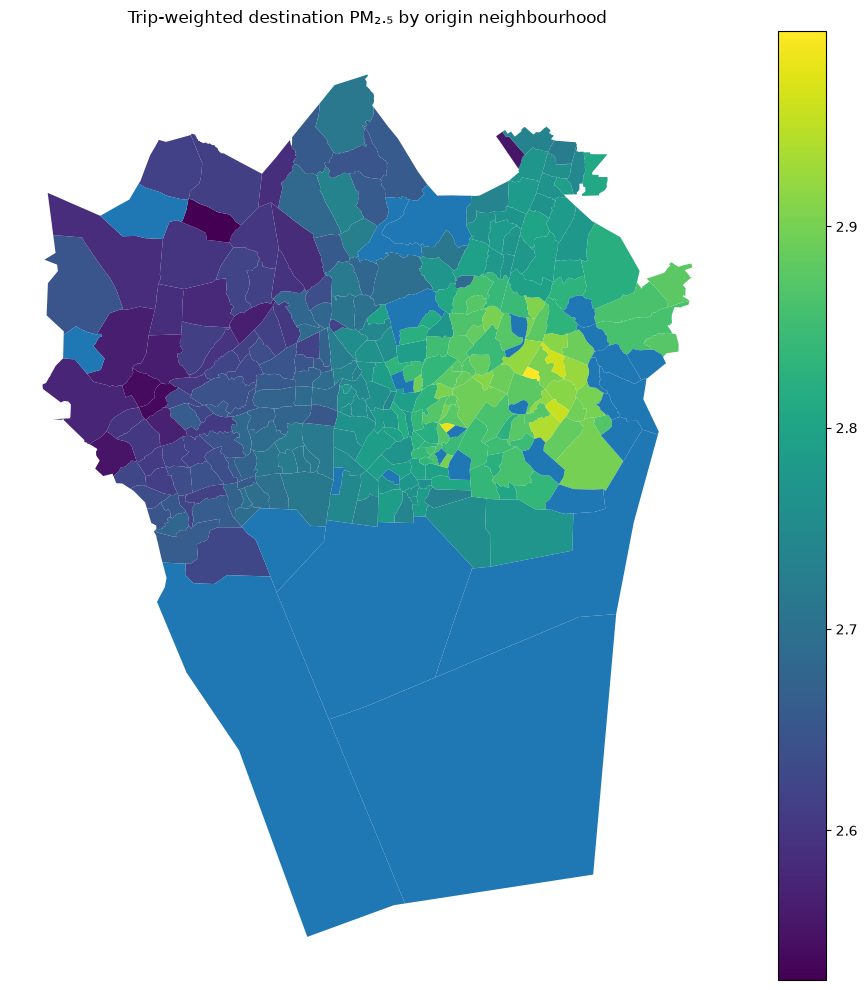

In [11]:
map_exposure = units.merge(
    origin_exposure[
        ["origin", "trip_weighted_destination_pm25", "coverage_pct"]
    ],
    left_on="unit_id",
    right_on="origin",
    how="left"
)

fig, ax = plt.subplots(figsize=(11, 10))

map_exposure.plot(
    column="trip_weighted_destination_pm25",
    legend=True,
    ax=ax,
    missing_kwds={"label": "No data"}
)

ax.set_title("Trip-weighted destination PM₂.₅ by origin neighbourhood")
ax.set_axis_off()

plt.tight_layout()
plt.show()

### Interpretation guardrails

- `trip_weighted_destination_pm25` is a **destination-exposure indicator**, not exposure during travel.
- `mobility_exposure_change` compares the PM₂.₅ sampled at the origin neighbourhood with the PM₂.₅ of destinations weighted by trip volume.
- The CAFEIN sample OD table has hour-of-day information but is not a date-specific event panel here, so this notebook does **not** establish behavioural response to a smoke or heat event.
- The `presence` table is loaded as in the original workflow but is not yet used in this analysis; it is a natural next extension for activity-space exposure.
